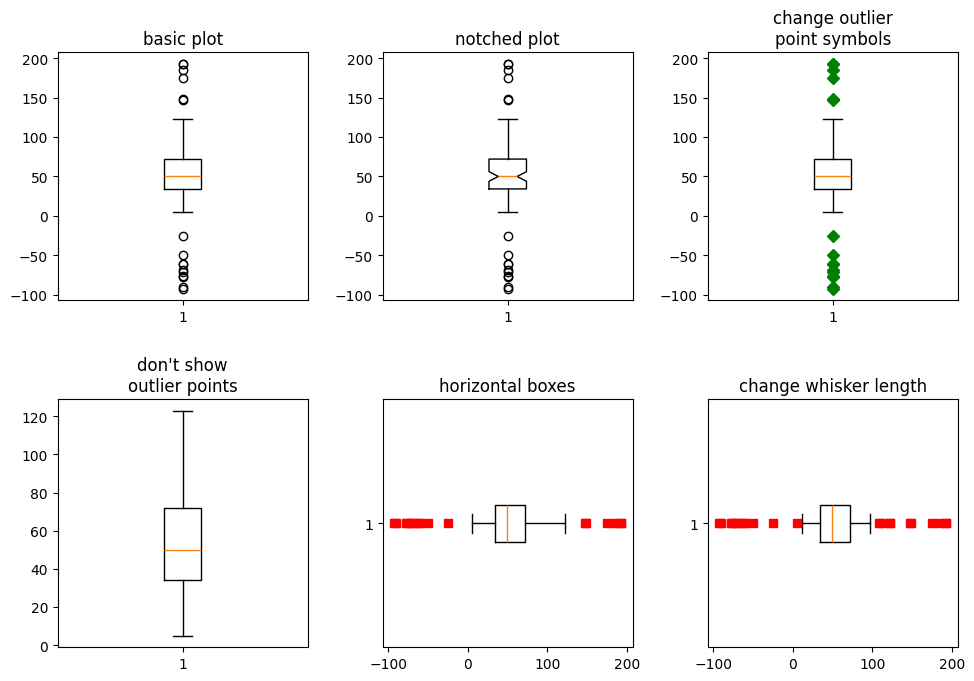

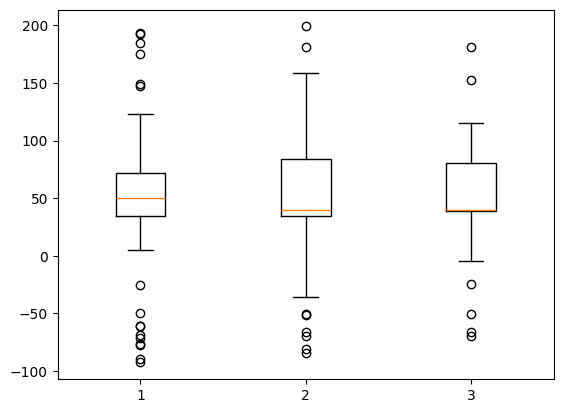

In [35]:
# fmt: off
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# Fixing random state for reproducibility
np.random.seed(19680801)

# Fake up some data
spread = np.random.rand(50) * 100           # 50 numbers from 0 to 99.99
center = np.ones(25) * 50                   # 25 numbers equal to 50
flier_high = np.random.rand(10) * 100 + 100 # 10 numbers from 100 to 199.99
flier_low = np.random.rand(10) * -100       # 10 numbers from -99.99 to 0
data = np.concatenate((spread, center, flier_high, flier_low))

fig, axs = plt.subplots(2, 3, figsize=(10, 7))

# Basic plot
axs[0, 0].boxplot(data)
axs[0, 0].set_title("basic plot")

# Notched plot
axs[0,1].boxplot(data,notch=True)
axs[0,1].set_title("notched plot")

# Change outlier point symbols
axs[0,2].boxplot(data,sym="gD")
axs[0,2].set_title("change outlier\npoint symbols")

# Don't show outlier symbols
axs[1,0].boxplot(data,sym="")
axs[1,0].set_title("don't show\noutlier points")

# Horizontal boxes
axs[1,1].boxplot(data,sym="rs",orientation="horizontal")
axs[1,1].set_title("horizontal boxes")

# Change whisker length
axs[1,2].boxplot(data,sym="rs",orientation="horizontal",whis=0.75)
axs[1,2].set_title("change whisker length")

fig.subplots_adjust(left=0.08,right=0.98,bottom=0.05,top=0.9,hspace=0.4,wspace=0.3)

# Fake up some more data
spread = np.random.rand(50) * 100           # 50 numbers from 0 to 99.99
center = np.ones(25) * 40                   # 25 numbers equal to 40
flier_high = np.random.rand(10) * 100 + 100 # 10 numbers from 100 to 199.99
flier_low = np.random.rand(10) * -100       # 10 numbers from -99.99 to 0
d2 = np.concatenate((spread, center, flier_high, flier_low))

data=[data,d2,d2[::2]]

# Multiple boxplots on one Axes
fig,ax=plt.subplots()
ax.boxplot(data)

plt.show()

<h3 style="font-weight:600;color:#FF5533">IID BOOTSTRAP RESAMPLE</h3>

> **IID**: Independent & Identically Distributed Bootstrap<br/>
    This is a resampling technique used to estimate the sampling distribution of a statistic<br/>
    by repeatedly drawing samples *with replacement* from the original data, treating the original<br/>
    data as the population.


We will use five different probability distributions to generate data and perform an IID bootstrap resample of the data to show that the original distributional properties of the sample are preserved.

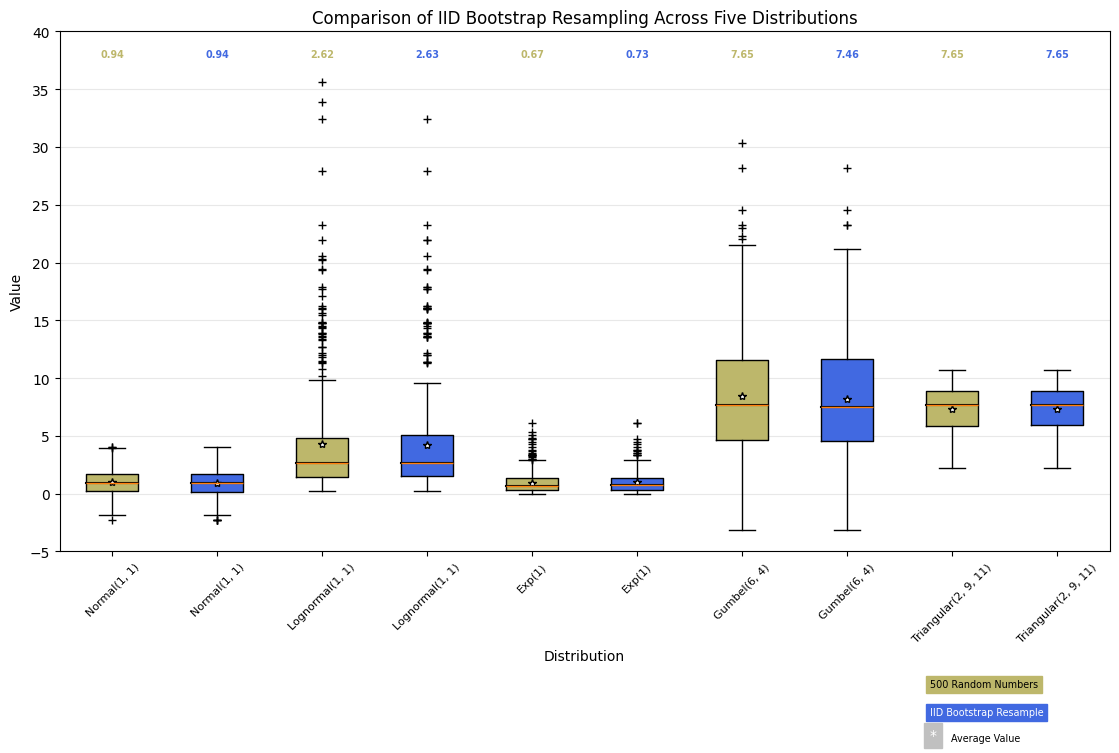

In [57]:
#fmt: off

random_dists = [
    "Normal(1, 1)",
    "Lognormal(1, 1)",
    "Exp(1)",
    "Gumbel(6, 4)",
    "Triangular(2, 9, 11)",
]

N = 500

norm = np.random.normal(1, 1, N)          # 500 samples from a Normal distribution with mean=1, std=1
logn = np.random.lognormal(1, 1, N)       # 500 samples from the Lognormal distribution with mean=1, std=1
expo = np.random.exponential(1, N)        # 500 samples from the Exponential distribution with scale=1
gumb = np.random.gumbel(6, 4, N)          # 500 samples from a Gumbel distribution with mean=6, std=4
tria = np.random.triangular(2, 9, 11, N)  # 500 samples from a Triangular distribution with lower limit=2,
                                          # peak at 9, and upper limit=11

# Generate some random indices that we'll use to resample the original data arrays.
# For code brevity, just use the same random indices for each array.
bootstrap_indices = np.random.randint(0, N, N)
data=[
    norm, norm[bootstrap_indices],
    logn, logn[bootstrap_indices],
    expo, expo[bootstrap_indices],
    gumb, gumb[bootstrap_indices],
    tria, tria[bootstrap_indices],
]

fig,ax1=plt.subplots(figsize=(12,8))
fig.canvas.manager.set_window_title("A Boxplot Example") # type: ignore
fig.subplots_adjust(left=0.075, right=0.95, top=0.9, bottom=0.25)

bp = ax1.boxplot(data, notch=False, sym="+", orientation="vertical", whis=1.5)
plt.setp(bp["boxes"], color="black")
plt.setp(bp["whiskers"], color="black")
plt.setp(bp["fliers"], color="red", marker="+")

# Add a horizontal grid to the plot, but make it very light in color
# so we can use it for reading data values but not be distracting.
ax1.yaxis.grid(True, linestyle="-", which="major", color="lightgrey", alpha=0.5)

ax1.set(
    axisbelow=True, # Hide the grid behind plot objects
    title="Comparison of IID Bootstrap Resampling Across Five Distributions",
    xlabel="Distribution",
    ylabel="Value",
)

# Now fill the boxes with desired colors
box_colors = ["darkkhaki", "royalblue"]
num_boxes = len(data)
medians = np.empty(num_boxes)

for i in range(num_boxes):
    box=bp["boxes"][i]
    box_x=[]
    box_y=[]

    for j in range(5):
        box_x.append(box.get_xdata()[j])
        box_y.append(box.get_ydata()[j])

    box_coords=np.column_stack([box_x, box_y])

    # Alternate between Dark Khaki and Royal Blue
    ax1.add_patch(Polygon(box_coords, facecolor=box_colors[i % 2]))

    # Now draw the median lines back over what we just filled in
    med=bp["medians"][i]
    median_x=[]
    median_y=[]

    for j in range(2):
        median_x.append(med.get_xdata()[j])
        median_y.append(med.get_ydata()[j])
        ax1.plot(median_x,median_y,"k")

    medians[i]=median_y[0]

    # Finally, overplot the sample averages, with horizontal alignment
    # in the center of each box.
    ax1.plot(np.average(med.get_xdata()), np.average(data[i]), color="w", marker="*", markeredgecolor="k")

# Set the axes ranges and axes labels
ax1.set_xlim(0.5, num_boxes + 0.5)
top=40
bottom=-5
ax1.set_ylim(bottom, top)
ax1.set_xticklabels(np.repeat(random_dists, 2), rotation=45, fontsize=8)

# Due to the y-axis scale being different across samples, it can be
# hard to compare diffeences in medians across the samples. Add upper
# x-axis tick labels with the sample medians to aid in comparison
# (just use 2 decimal places of precision)
pos=np.arange(num_boxes) +1
upper_labels=[str(round(s,2)) for s in medians]
weights=["bold","semibold"]

for tick, label in zip(range(num_boxes), ax1.get_xticklabels()):
    k=tick % 2
    ax1.text(
        pos[tick],
        0.95,
        upper_labels[tick],
        transform=ax1.get_xaxis_transform(),
        horizontalalignment="center",
        size="x-small",
        weight=weights[k],
        color=box_colors[k],
    )

# Finally, add a basic legend
fig.text(0.80,0.08,f"{N} Random Numbers",backgroundcolor=box_colors[0],color="black",weight="roman",size="x-small")
fig.text(0.80,0.045,"IID Bootstrap Resample",backgroundcolor=box_colors[1],color="white",weight="roman",size="x-small")
fig.text(0.80,0.015,"*",color="white",backgroundcolor="silver",weight="roman",size="medium")
fig.text(0.815,0.013," Average Value",color="black",weight="roman",size="x-small")

plt.show()